In [ ]:
from PIL import Image
import numpy as np

# =========================
# CONFIG
# =========================

I, J = 300, 300
N = I * J
D = 2

sigma2 = (0.5/I)**2
lr = 0.03

img = Image.open("Lena.png").convert("L")
img = img.resize((I, J))
img = np.array(img) / 255.0  # [0,1]

V =  1 - img

In [32]:
V.shape

(300, 300)

In [33]:
import jax.numpy as jnp

V = jnp.array(V)

def external_potential_grad(x, A = 0.01):
    # x: (I, J, 2) dans [0,1]^2
    i = (x[..., 0] * (I - 1)).astype(jnp.int32)
    j = (x[..., 1] * (J - 1)).astype(jnp.int32)

    V_local = V[i, j]

    # gradient approx par différences finies sur image
    gx = jnp.roll(V, -1, axis=0) - jnp.roll(V, 1, axis=0)
    gy = jnp.roll(V, -1, axis=1) - jnp.roll(V, 1, axis=1)

    gx = gx[i, j]
    gy = gy[i, j]

    return A*jnp.stack([gx, gy], axis=-1)

## Let find the ground state (here blue noise) of a particule system

We will perform standard gradient descent with jax

In [34]:
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax, vmap
from functools import partial

from squarenet import SquareNet

In [37]:
# =========================
# DATA
# =========================

pts = np.random.rand(N, D)


# =========================
# INITIAL STRUCTURE (SquareNet)
# =========================

sqnet = SquareNet(IJ_=(I, J))
sqnet.fit(pts)

points = sqnet.map(pts).reshape(I, J, D)


# =========================
# GRID SHIFTS
# =========================

wr = 10
shifts = jnp.array([
    (di, dj)
    for di in range(-wr, wr+1)
    for dj in range(-wr, wr+1)
    if (di, dj) != (0, 0)
])


# =========================
# INTERACTION (stable form)
# =========================

def interaction(x, y, sigma2):
    delta = (y - x + 0.5) % 1.0 - 0.5
    dist2 = jnp.sum(delta ** 2, axis=-1, keepdims=True)

    w = jnp.exp(-dist2 / sigma2)
    return (2.0/sigma2)*(delta * w) 

def compute_grad(x, sigma2):

    def one_shift(s):
        di, dj = s
        y = jnp.roll(x, (di, dj), axis=(0, 1))
        return interaction(x, y, sigma2)

    grads = vmap(one_shift)(shifts)

    grad = jnp.mean(grads, axis=0)
    grad += external_potential_grad(x, A=1)
    
    return grad


# =========================
# ground_stateATION STEP
# =========================

@partial(jax.jit, static_argnames=("max_iter",))
def ground_state(x, max_iter=10, lr=0.1, sigma2=1e-2):

    def step(_, x):
        g = compute_grad(x, sigma2)
        x = x - lr * g

        return x%1

    return lax.fori_loop(0, max_iter, step, x)

# =========================
# INITIAL ground_stateATION
# =========================

points = ground_state(points, max_iter=10, lr=lr, sigma2=sigma2)


# =========================
# SCHEDULE
# =========================

lr_list = np.logspace(-2, -4, 10)


# =========================
# MAIN LOOP
# =========================

for i, lr in enumerate(lr_list):

    print(f"Step {i} | lr={lr:.3f}")

    # 1) structure update (occasionnel)
    flat = points.reshape(-1, D)

    sqnet = SquareNet(IJ_=(I, J), warnings_ = False)
    sqnet.fit(flat)

    points = sqnet.map(flat).reshape(I, J, D)

    # 2) physical ground_stateation
    points = ground_state(points, max_iter=10, lr=lr, sigma2=sigma2)

succesfully sorted at iteration 10
Step 0 | lr=0.010
succesfully sorted at iteration 9
Step 1 | lr=0.006
succesfully sorted at iteration 10
Step 2 | lr=0.004
succesfully sorted at iteration 10
Step 3 | lr=0.002
succesfully sorted at iteration 9
Step 4 | lr=0.001
succesfully sorted at iteration 9
Step 5 | lr=0.001
succesfully sorted at iteration 8
Step 6 | lr=0.000
succesfully sorted at iteration 7
Step 7 | lr=0.000
succesfully sorted at iteration 6
Step 8 | lr=0.000
succesfully sorted at iteration 6
Step 9 | lr=0.000
succesfully sorted at iteration 6


## Let look at the beautiful blue noise we just generated

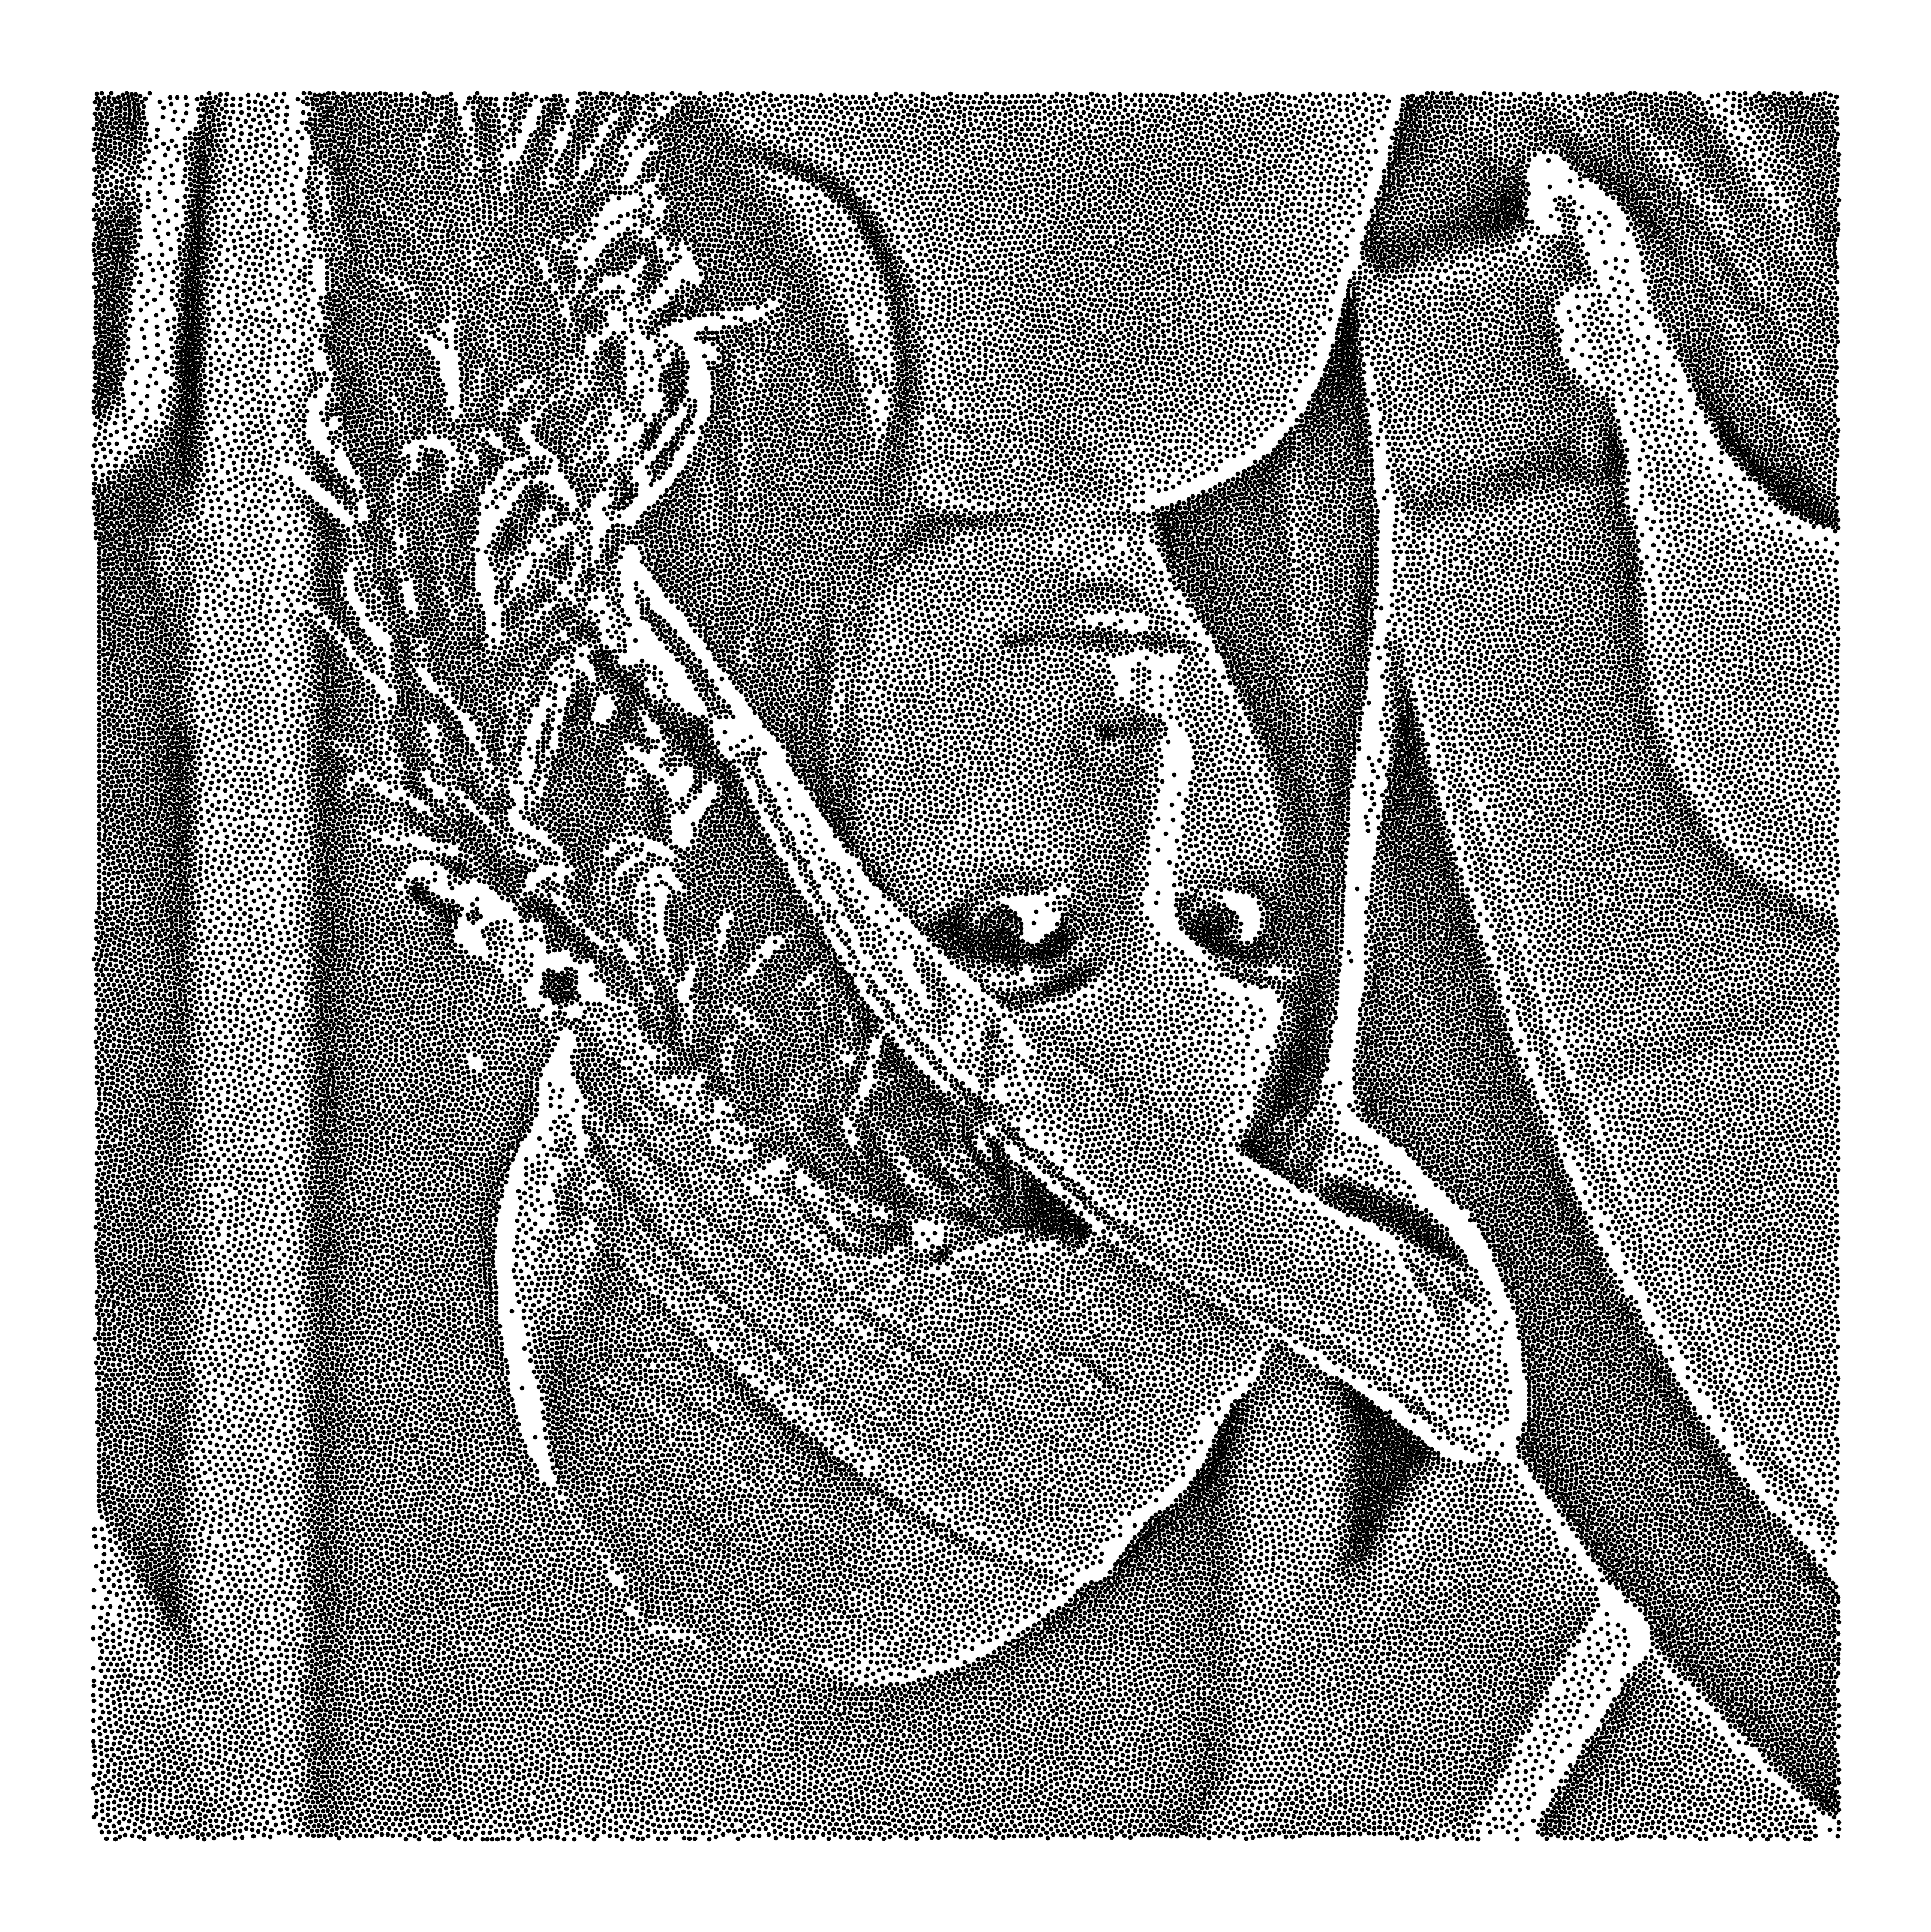

In [43]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(32, 32))
ax = fig.add_axes([0, 0, 1, 1])  
ax.set_aspect("equal")
ax.set_axis_off()

ax.scatter(points[..., 1].ravel(),
            points[..., 0].ravel(),
            s=20, color="black")
saving = False
if saving:
    plt.savefig(
        "another_blue_noise.png",
        dpi=300,
        bbox_inches=None,   # IMPORTANT
        pad_inches=0
    )
plt.show()